Optimal Portfolio Weights: [0.27063007 0.36139421 0.36797572]
Expected Portfolio Return: 0.1202
Portfolio Variance: 0.0818
Sharpe Ratio: 0.3503


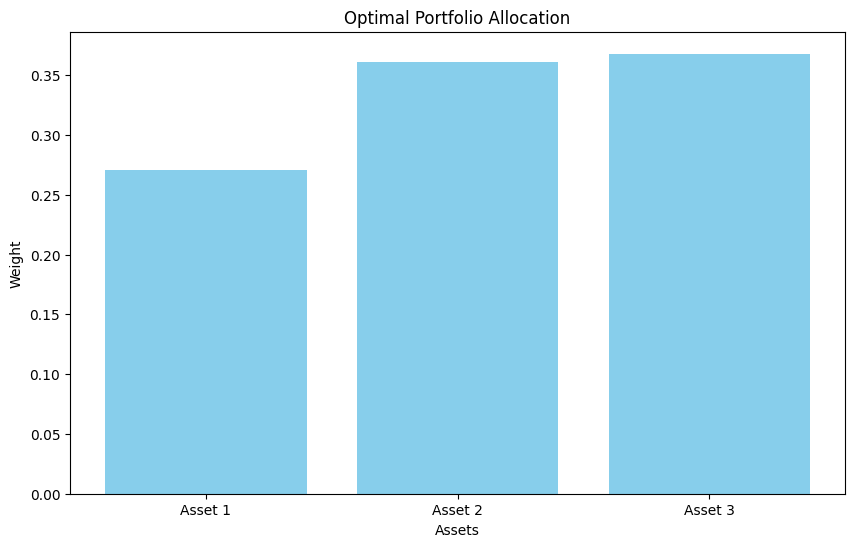

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Example data: Expected returns and covariance matrix for three assets
expected_returns = np.array([0.08, 0.12, 0.15])  # Expected returns of assets
cov_matrix = np.array([[0.1, 0.02, 0.04],
                       [0.02, 0.15, 0.06],
                       [0.04, 0.06, 0.2]])  # Covariance matrix of asset returns

# Number of assets
num_assets = len(expected_returns)

# Portfolio return calculation
def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)

# Portfolio variance calculation
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# Objective function to minimize (negative Sharpe ratio)
def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate=0.02):
    port_return = portfolio_return(weights, expected_returns)
    port_variance = portfolio_variance(weights, cov_matrix)
    sharpe_ratio = (port_return - risk_free_rate) / np.sqrt(port_variance)
    return -sharpe_ratio

# Constraints: Weights sum to 1
def constraint_sum_weights(weights):
    return np.sum(weights) - 1

# Bounds for weights: Each weight between 0 and 1
bounds = [(0, 1) for _ in range(num_assets)]

# Initial guess (equal allocation)
initial_weights = np.array([1 / num_assets] * num_assets)

# Optimization
constraints = ({'type': 'eq', 'fun': constraint_sum_weights})
result = minimize(negative_sharpe_ratio, initial_weights, args=(expected_returns, cov_matrix),
                  bounds=bounds, constraints=constraints)

# Optimal weights
optimal_weights = result.x
optimal_return = portfolio_return(optimal_weights, expected_returns)
optimal_variance = portfolio_variance(optimal_weights, cov_matrix)
optimal_sharpe = (optimal_return - 0.02) / np.sqrt(optimal_variance)

# Results
print("Optimal Portfolio Weights:", optimal_weights)
print("Expected Portfolio Return:", round(optimal_return, 4))
print("Portfolio Variance:", round(optimal_variance, 4))
print("Sharpe Ratio:", round(optimal_sharpe, 4))

# Visualization
plt.figure(figsize=(10, 6))
labels = [f"Asset {i+1}" for i in range(num_assets)]
plt.bar(labels, optimal_weights, color='skyblue')
plt.title('Optimal Portfolio Allocation')
plt.ylabel('Weight')
plt.xlabel('Assets')
plt.show()
